## Тема занятия: пакетная нормализация в обучении нейронных сетей (Батч-нормализация)

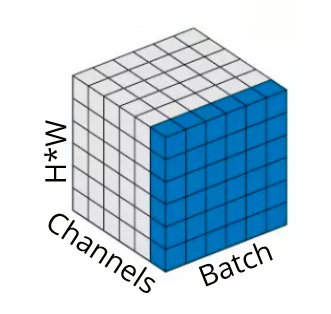

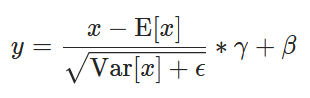

Внутренний ковариационный сдвиг — серьёзная проблема, с которой сталкиваются при обучении моделей глубокого обучения. Пакетная нормализация была введена для решения этой проблемы.

Пакетная нормализация была введена для смягчения проблемы внутреннего ковариационного сдвига в нейронных сетях Сергеем Иоффе и Кристианом Сегеди в 2015 году. Процесс нормализации включает вычисление среднего значения и дисперсии каждого признака в мини-пакете, а затем масштабирование и сдвиг признаков с использованием этой статистики. Это гарантирует, что входные данные для каждого слоя остаются примерно в том же распределении, независимо от изменений в распределении выходных данных более ранних слоёв. Следовательно, пакетная нормализация помогает стабилизировать процесс обучения, обеспечивая более высокую скорость обучения и более быструю сходимость.

**Необходимость в батч-нормализации**
Пакетная нормализация — это расширение концепции нормализации от входного слоя до активаций каждого скрытого слоя по всей нейронной сети. 

В традиционных нейронных сетях по мере распространения входных данных по сети распределение входов каждого слоя меняется. Это явление, известное как внутренний ковариационный сдвиг может замедлить процесс обучения (или даже препятствовать сходимости сети во время обучения). Пакетная нормализация направлена на смягчение этой проблемы путём нормализации входных данных каждого слоя. 

Входными данными для каждого скрытого слоя являются выходные данные предыдущего слоя. Если эти выходные данные нормализованы, это гарантирует, что сеть постоянно получает входные данные с одинаковым распределением, независимо от этапа обучения. Такая стабильность распределения входных данных обеспечивает более плавное и эффективное обучение.

При применении пакетной нормализации к скрытым слоям сети градиенты, распространяющиеся во время обратного распространения ошибки, с меньшей вероятностью будут исчезать или увеличиваться, что приводит к более стабильной динамике обучения. В конечном итоге это способствует более быстрой сходимости и повышению производительности нейронной сети при выполнении заданной задачи.

Будем использовать код из предыдущего занятия.<br>
Изменим архитектуру : добавим **батч-нормализацию** (torch.nn.BatchNorm2d)

In [1]:
import torch
import random
import numpy as np


def pick_device():
    """Приоритет: CUDA → Apple MPS (Apple Silicon) → CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    torch.backends.cudnn.deterministic = True

In [2]:
import torchvision.datasets

In [3]:
MNIST_train = torchvision.datasets.MNIST('./', download=False, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=False, train=False)


In [4]:
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

In [5]:
len(y_train), len(y_test)

(60000, 10000)

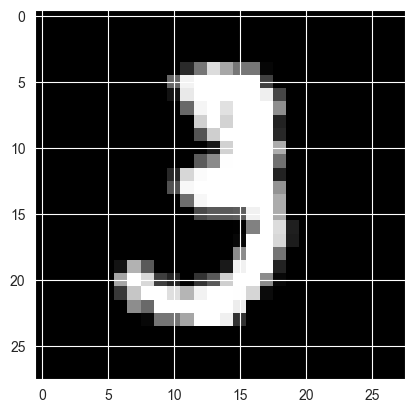

tensor(3)


In [6]:
import matplotlib.pyplot as plt
plt.imshow(X_train[10, :, :])
plt.gray()
plt.show()
print(y_train[10])

In [7]:
X_train = X_train.unsqueeze(1).float()
X_test = X_test.unsqueeze(1).float()

In [8]:
X_train.shape

torch.Size([60000, 1, 28, 28])

In [9]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = torch.nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.act1  = torch.nn.Tanh()
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=0)
        self.act2  = torch.nn.Tanh()
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1   = torch.nn.Linear(5 * 5 * 16, 120)
        self.act3  = torch.nn.Tanh()

        self.fc2   = torch.nn.Linear(120, 84)
        self.act4  = torch.nn.Tanh()

        self.fc3   = torch.nn.Linear(84, 10)



    def forward(self, x):

        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)

        return x

lenet5 = LeNet5()

In [14]:
device = pick_device()
print("device:", device)
lenet5 = lenet5.to(device)

device: mps


In [15]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [16]:
batch_size = 100

test_accuracy_history = []
test_loss_history = []

X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(15):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()

        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)

        preds = lenet5.forward(X_batch)

        loss_value = loss(preds, y_batch)
        loss_value.backward()

        optimizer.step()

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())

    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    print(accuracy)

tensor(0.9750)
tensor(0.9829)
tensor(0.9852)
tensor(0.9874)
tensor(0.9886)
tensor(0.9879)
tensor(0.9878)
tensor(0.9888)
tensor(0.9878)
tensor(0.9875)
tensor(0.9887)
tensor(0.9885)
tensor(0.9881)
tensor(0.9883)
tensor(0.9907)


In [17]:
lenet5.forward(X_test)

tensor([[-2.1867,  0.1751, -0.5264,  ..., 15.1436, -3.5007,  5.5720],
        [ 0.1325, -0.1847, 17.1136,  ..., -2.0154,  1.4682, -4.8487],
        [-2.7774, 15.9507, -2.6994,  ...,  1.6755,  2.0234, -2.3384],
        ...,
        [-4.8602, -1.3515, -4.2696,  ...,  0.5231,  1.1291,  3.6638],
        [-1.7251, -3.4848, -6.2317,  ..., -6.0590,  2.3317, -2.1789],
        [ 2.2885, -5.6885,  0.3381,  ..., -7.4160, -1.5855, -4.2606]],
       device='mps:0', grad_fn=<LinearBackward0>)

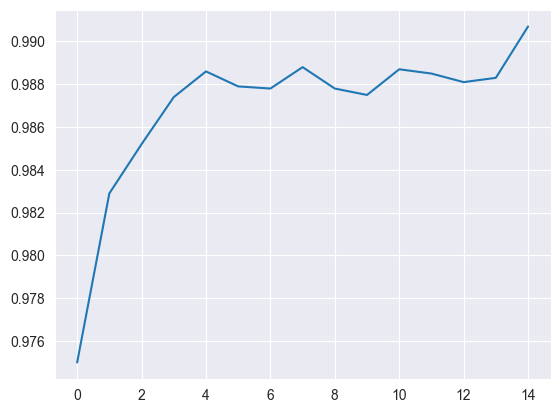

In [18]:
plt.plot(test_accuracy_history);

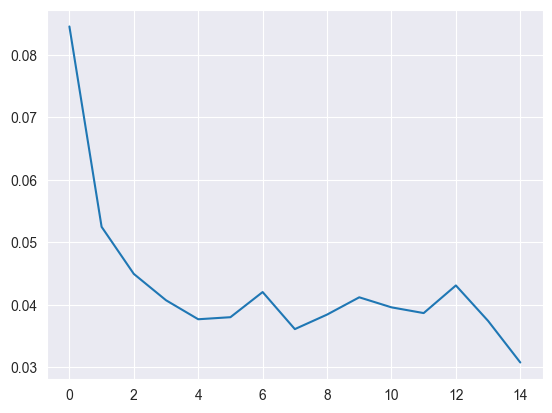

In [19]:
plt.plot(test_loss_history);

## Задание 1

Провести исследование влияния гиперпараметров на сходимость икачесвто сети при обучении на MNIST
1. Функции activation = 'tanh', 'relu'
2. Вид пуллинга    pooling = 'avg','max'
3. Свертки  conv_size  = 5, каскад сверток conv_size  = 3
4. Слой batch_normalization
5. Логгировать обучение с помощью TensorBoard.

In [23]:
import os, sys, shutil, pathlib
tb = shutil.which("tensorboard")
if tb is None:
    # чаще всего бинарник лежит рядом с python ядра
    candidate = pathlib.Path(sys.executable).with_name("tensorboard")
    if candidate.exists():
        tb = str(candidate)
    else:
        # fallback для macOS user install
        fallback = pathlib.Path.home() / "Library/Python/3.9/bin/tensorboard"
        if fallback.exists():
            tb = str(fallback)
print("Using TENSORBOARD_BINARY:", tb)
os.environ["TENSORBOARD_BINARY"] = tb if tb else ""

Using TENSORBOARD_BINARY: /Users/bereznevn/Library/Python/3.9/bin/tensorboard


In [24]:
from torch.utils.tensorboard import SummaryWriter
import torch.nn as nn
import pandas as pd

# нормализация входов (в базовом цикле выше данные в 0..255)
X_train_n = X_train / 255.0
X_test_n = X_test / 255.0


def make_act(name: str):
    if name == "tanh":
        return nn.Tanh()
    if name == "relu":
        return nn.ReLU()
    raise ValueError(name)


def make_pool(name: str):
    if name == "avg":
        return nn.AvgPool2d(kernel_size=2, stride=2)
    if name == "max":
        return nn.MaxPool2d(kernel_size=2, stride=2)
    raise ValueError(name)


class FlexibleLeNet5(nn.Module):

    def __init__(
        self,
        activation: str = "tanh",
        pooling: str = "avg",
        conv_size: int = 5,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        self.conv_size = conv_size
        self.use_batchnorm = use_batchnorm
        self.act = make_act(activation)
        self.pool = make_pool(pooling)

        if conv_size == 5:
            self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
            self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)
        elif conv_size == 3:
            self.conv1_1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
            self.conv1_2 = nn.Conv2d(6, 6, kernel_size=3, padding=1)
            self.conv2_1 = nn.Conv2d(6, 16, kernel_size=3, padding=0)
            self.conv2_2 = nn.Conv2d(16, 16, kernel_size=3, padding=0)
        else:
            raise ValueError(conv_size)

        self.bn1 = nn.BatchNorm2d(6)
        self.bn2 = nn.BatchNorm2d(16)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        if self.conv_size == 5:
            x = self.conv1(x)
            if self.use_batchnorm:
                x = self.bn1(x)
            x = self.act(x)
            x = self.pool(x)
            x = self.conv2(x)
            if self.use_batchnorm:
                x = self.bn2(x)
            x = self.act(x)
            x = self.pool(x)
        else:
            x = self.conv1_1(x)
            x = self.conv1_2(x)
            if self.use_batchnorm:
                x = self.bn1(x)
            x = self.act(x)
            x = self.pool(x)
            x = self.conv2_1(x)
            x = self.conv2_2(x)
            if self.use_batchnorm:
                x = self.bn2(x)
            x = self.act(x)
            x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        return x


def run_experiment(cfg, X_tr, y_tr, X_te, y_te, epochs=15, batch_size=512, lr=1e-3):
    device = pick_device()
    model = FlexibleLeNet5(
        activation=cfg["activation"],
        pooling=cfg["pooling"],
        conv_size=cfg["conv_size"],
        use_batchnorm=cfg["use_batchnorm"],
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    run_name = (
        f"a{cfg['activation']}_p{cfg['pooling']}_c{cfg['conv_size']}"
        f"_bn{int(cfg['use_batchnorm'])}"
    )
    writer = SummaryWriter(log_dir=f"runs/lab06_mnist_hyperparams/{run_name}")

    X_tr_d = X_tr.to(device)
    y_tr_d = y_tr.to(device)
    X_te_d = X_te.to(device)
    y_te_d = y_te.to(device)

    best_acc = 0.0
    for epoch in range(epochs):
        model.train()
        order = np.random.permutation(len(X_tr_d))
        epoch_loss = 0.0
        n_batches = 0
        for start in range(0, len(X_tr_d), batch_size):
            idx = order[start : start + batch_size]
            xb = X_tr_d[idx]
            yb = y_tr_d[idx]
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
            n_batches += 1

        avg_train_loss = epoch_loss / max(n_batches, 1)
        model.eval()
        with torch.no_grad():
            test_logits = model(X_te_d)
            test_loss = loss_fn(test_logits, y_te_d).item()
            acc = (test_logits.argmax(dim=1) == y_te_d).float().mean().item()

        best_acc = max(best_acc, acc)
        writer.add_scalar("loss/train", avg_train_loss, epoch)
        writer.add_scalar("loss/test", test_loss, epoch)
        writer.add_scalar("accuracy/test", acc, epoch)
        print(run_name, "epoch", epoch, "test acc", f"{acc:.4f}")

    writer.close()
    if device.type == "mps":
        torch.mps.empty_cache()
    return best_acc


experiments = []
for act in ("tanh", "relu"):
    for pool in ("avg", "max"):
        for conv in (5, 3):
            for bn in (False, True):
                experiments.append(
                    {
                        "activation": act,
                        "pooling": pool,
                        "conv_size": conv,
                        "use_batchnorm": bn,
                    }
                )

print("MNIST hyperparameter search — устройство:", pick_device())

results = []
for cfg in experiments:
    print("===", cfg, "===")
    best = run_experiment(cfg, X_train_n, y_train, X_test_n, y_test)
    results.append({**cfg, "best_test_accuracy": best})

results_df = pd.DataFrame(results)
results_df.sort_values("best_test_accuracy", ascending=False)

MNIST hyperparameter search — устройство: mps
=== {'activation': 'tanh', 'pooling': 'avg', 'conv_size': 5, 'use_batchnorm': False} ===
atanh_pavg_c5_bn0 epoch 0 test acc 0.9160
atanh_pavg_c5_bn0 epoch 1 test acc 0.9437
atanh_pavg_c5_bn0 epoch 2 test acc 0.9640
atanh_pavg_c5_bn0 epoch 3 test acc 0.9687
atanh_pavg_c5_bn0 epoch 4 test acc 0.9731
atanh_pavg_c5_bn0 epoch 5 test acc 0.9774
atanh_pavg_c5_bn0 epoch 6 test acc 0.9806
atanh_pavg_c5_bn0 epoch 7 test acc 0.9813
atanh_pavg_c5_bn0 epoch 8 test acc 0.9830
atanh_pavg_c5_bn0 epoch 9 test acc 0.9829
atanh_pavg_c5_bn0 epoch 10 test acc 0.9848
atanh_pavg_c5_bn0 epoch 11 test acc 0.9840
atanh_pavg_c5_bn0 epoch 12 test acc 0.9854
atanh_pavg_c5_bn0 epoch 13 test acc 0.9869
atanh_pavg_c5_bn0 epoch 14 test acc 0.9857
=== {'activation': 'tanh', 'pooling': 'avg', 'conv_size': 5, 'use_batchnorm': True} ===
atanh_pavg_c5_bn1 epoch 0 test acc 0.9535
atanh_pavg_c5_bn1 epoch 1 test acc 0.9768
atanh_pavg_c5_bn1 epoch 2 test acc 0.9836
atanh_pavg_c5_bn

,activation,pooling,conv_size,use_batchnorm,best_test_accuracy
11,relu,avg,3,True,0.9933
1,tanh,avg,5,True,0.9918
15,relu,max,3,True,0.9918
9,relu,avg,5,True,0.9915
7,tanh,max,3,True,0.9912
3,tanh,avg,3,True,0.9910
5,tanh,max,5,True,0.9903
13,relu,max,5,True,0.9895
6,tanh,max,3,False,0.9892
2,tanh,avg,3,False,0.9891


In [2]:
"""TensorBoard: PyCharm часто показывает чёрный iframe у %%tensorboard — запускаем сервер отдельно и открываем браузер."""
import os
import socket
import subprocess
import sys
import time
import webbrowser
from pathlib import Path

from IPython.display import HTML, display
from IPython import get_ipython

TB_PORT = 6007


def _free_port(port: int) -> None:
    try:
        r = subprocess.run(
            ["lsof", "-ti", f":{port}"],
            capture_output=True,
            text=True,
            timeout=5,
        )
        for pid in r.stdout.split():
            if pid.isdigit():
                try:
                    os.kill(int(pid), 9)
                except (ProcessLookupError, ValueError, PermissionError):
                    pass
    except FileNotFoundError:
        pass


def _pick_logdir():
    roots = [Path.cwd() / "runs", Path.cwd() / "lab06" / "runs"]
    for root in roots:
        if root.is_dir() and list(root.rglob("events.out.tfevents.*")):
            return root.resolve(), True
    root = Path.cwd() / "runs"
    root.mkdir(parents=True, exist_ok=True)
    return root.resolve(), False


_free_port(TB_PORT)
_logdir, _has_events = _pick_logdir()
print("TensorBoard logdir:", _logdir)
print("Найдены event-файлы:", _has_events)

_ip = get_ipython()
if _ip is not None:
    _prev = _ip.user_ns.get("_TB_SUBPROC")
    if _prev is not None and getattr(_prev, "poll", lambda: 1)() is None:
        _prev.terminate()
        try:
            _prev.wait(timeout=3)
        except subprocess.TimeoutExpired:
            _prev.kill()

_cmd = [
    sys.executable,
    "-m",
    "tensorboard.main",
    "--logdir",
    str(_logdir),
    "--host",
    "127.0.0.1",
    "--port",
    str(TB_PORT),
]
_TB_SUBPROC = subprocess.Popen(_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
if _ip is not None:
    _ip.user_ns["_TB_SUBPROC"] = _TB_SUBPROC

_URL = f"http://127.0.0.1:{TB_PORT}/"
time.sleep(1.2)
_sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
_sock.settimeout(2)
_listening = _sock.connect_ex(("127.0.0.1", TB_PORT)) == 0
_sock.close()
print("Порт", TB_PORT, "слушается:", _listening)
print("URL:", _URL)
if _listening:
    webbrowser.open(_URL)
display(HTML(f'<p><b>Если окно не открылось:</b> <a href="{_URL}" target="_blank" rel="noopener">TensorBoard в браузере</a></p>'))
if _TB_SUBPROC.poll() is not None:
    print(
        "Процесс TensorBoard сразу завершился (код",
        _TB_SUBPROC.returncode,
        "). Установите tensorboard в том же venv, что и ядро: python -m pip install tensorboard",
    )


TensorBoard logdir: /Users/bereznevn/Documents/Универ/Лабы/Нейросетевые технологии/PyCharmMiscProject/lab06/runs
Найдены event-файлы: True
Порт 6007 слушается: False
URL: http://127.0.0.1:6007/


## Задание 2

Обучить вашу нейронную сеть на датасете Cifar10

In [21]:
CIFAR_train = torchvision.datasets.CIFAR10('./', download=True, train=True)
CIFAR_test = torchvision.datasets.CIFAR10('./', download=True, train=False)

100.0%


In [22]:
X_train = torch.FloatTensor(CIFAR_train.data)
y_train = torch.LongTensor(CIFAR_train.targets)
X_test = torch.FloatTensor(CIFAR_test.data)
y_test = torch.LongTensor(CIFAR_test.targets)

In [23]:
CIFAR_train.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [24]:
CIFAR_train.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..254.0].


tensor(9)


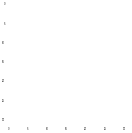

In [25]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(figsize = (8,8), dpi =20)
plt.imshow(X_train[1000, :, :])
print(y_train[1000])

In [26]:
# размерность тензора [N C W H]

In [27]:
X_train.shape

torch.Size([50000, 32, 32, 3])